In [25]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5
G_lo = 20.0

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [9]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [10]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [11]:
# z_array = [0,1]
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))
cmaps = [cmap_red, cmap_blue]

In [12]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)
blue = plt.get_cmap('Blues')((0.333+0.999)/2)
red = plt.get_cmap('Reds')((0.333+0.999)/2)
colors = [red, blue]
# mag = [G_hi, G_lo]
G_array = [G_lo, G_hi]

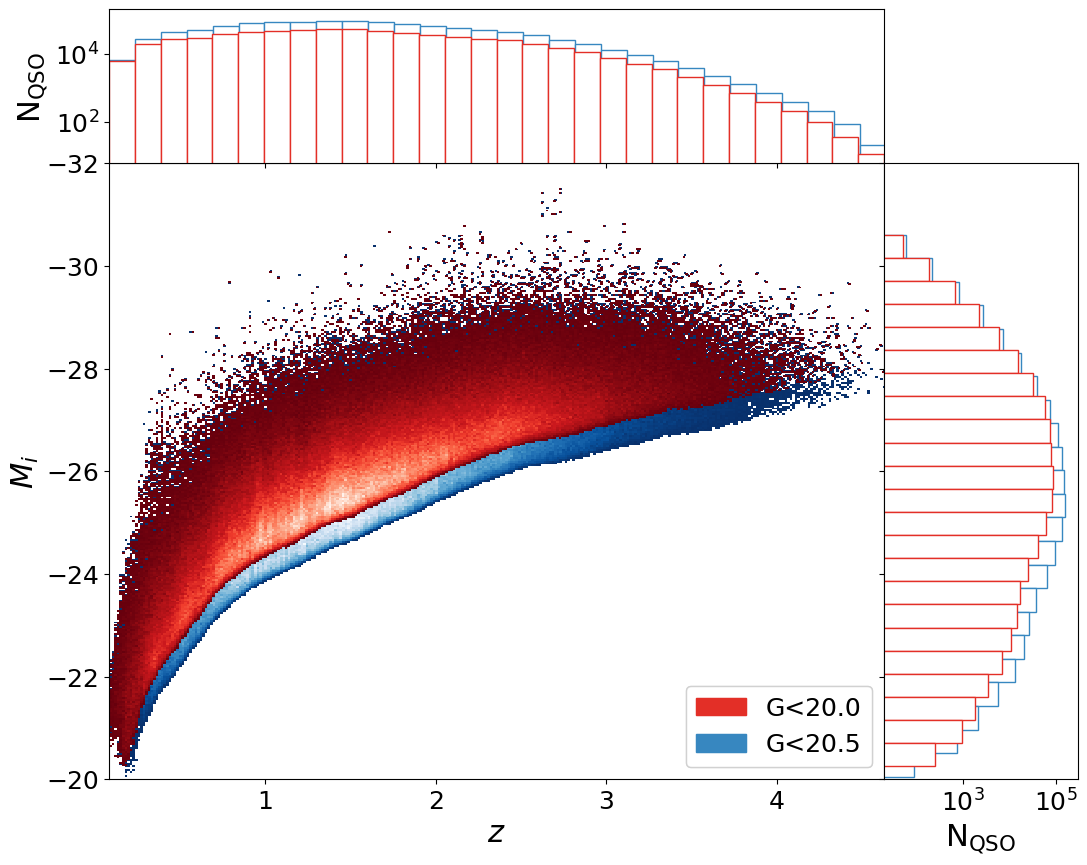

In [13]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
patch = [mpatches.Patch(color=colors[i], label='G<{}'.format(G_array[i])) for i in range(len(colors))] 
first_legend = ax1.legend(handles=patch, loc = 'lower right')
ax1.add_artist(first_legend)

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $\xi(s)$
### Fiducial

In [14]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

_G20.0_zmin0.0zmax1.0


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


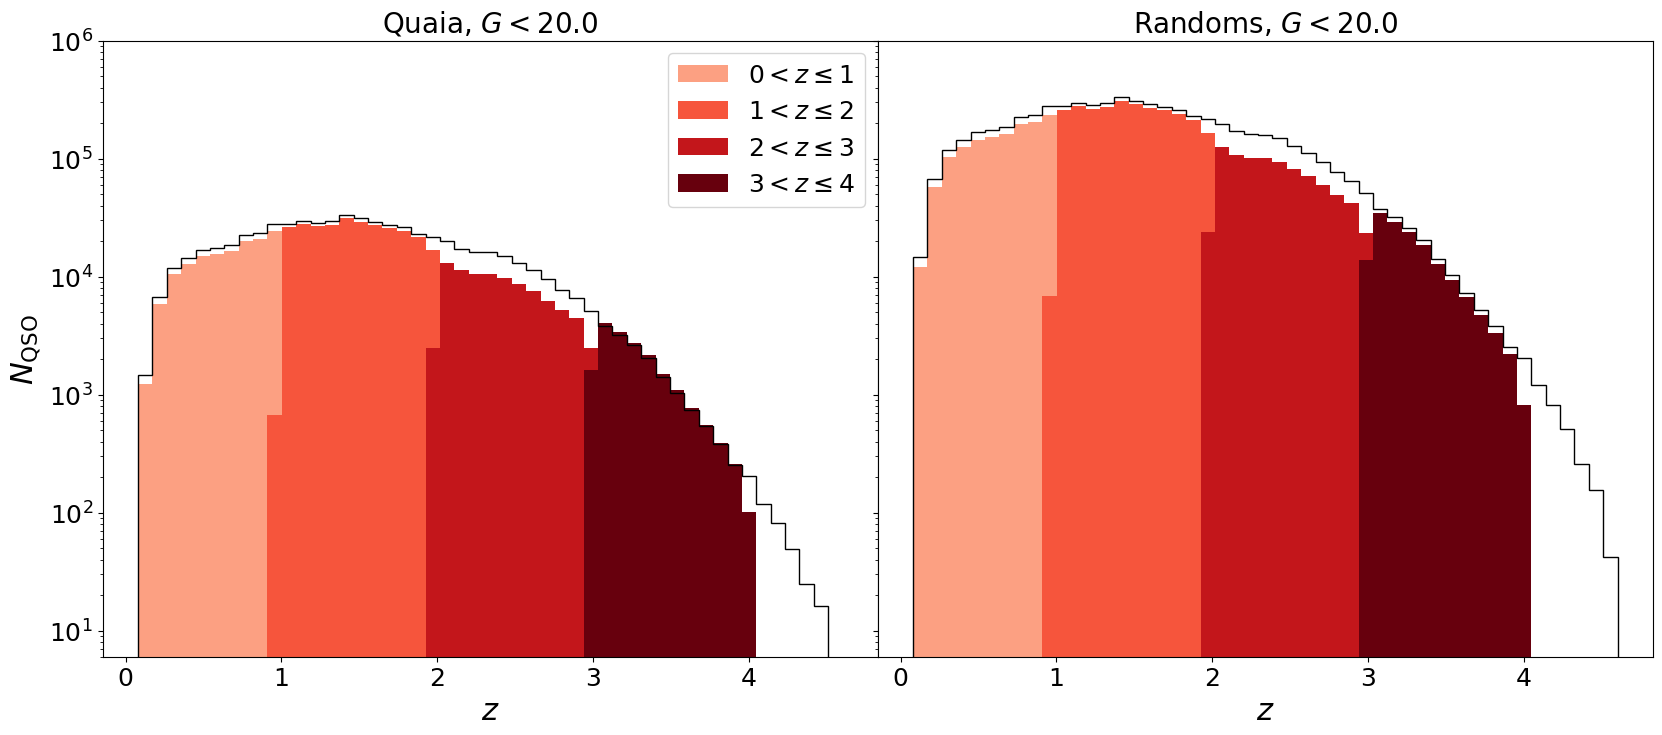

_G20.5_zmin0.0zmax1.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin1.0zmax2.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


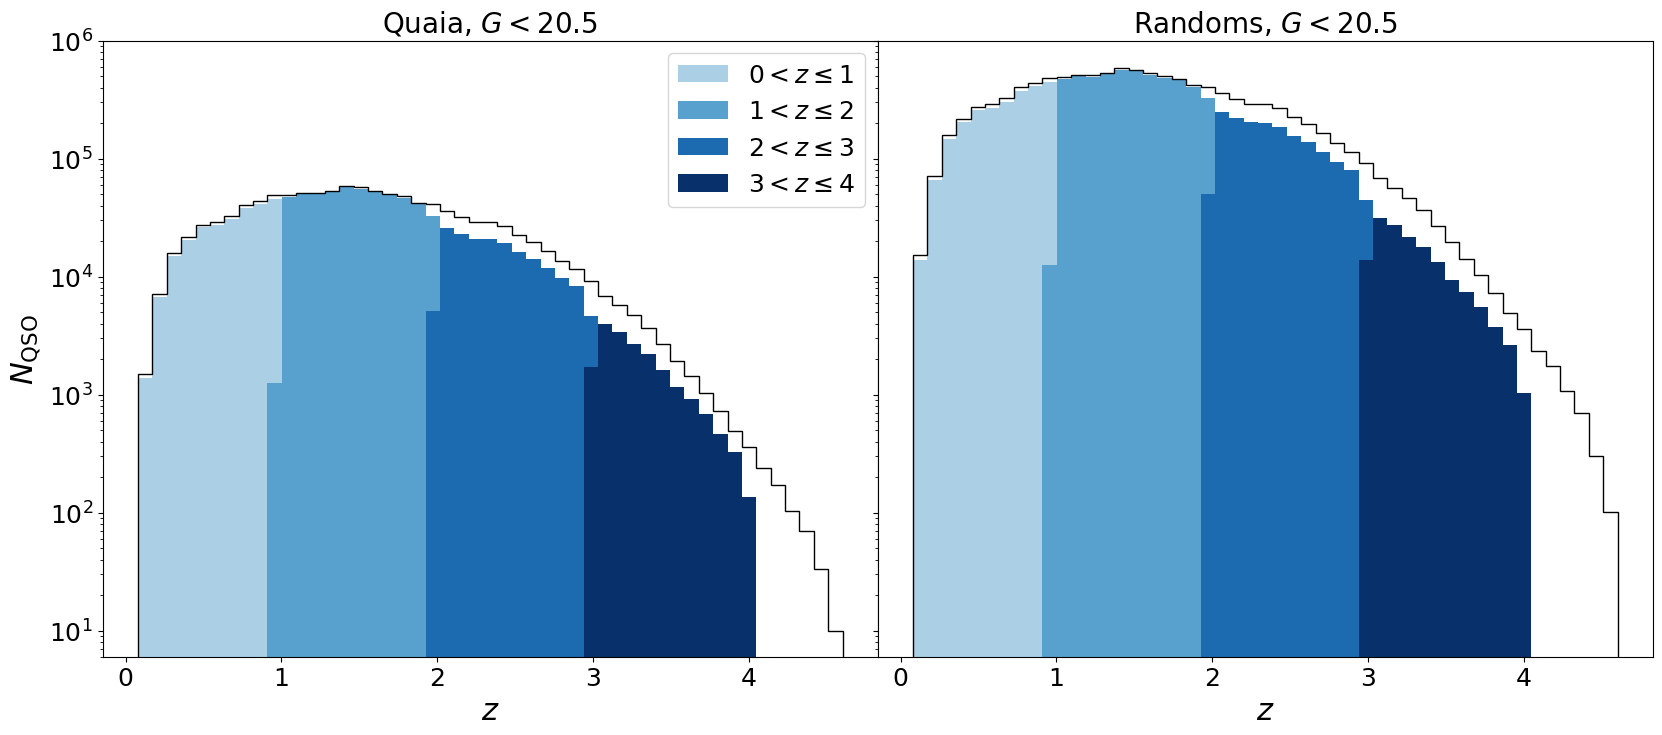

In [15]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = {20.0: [], 20.5: []}
for G, cmap in zip(G_array, cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_10x.fits'.format(G)
    tab_randhi = Table.read(fn_randhi)
    pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
             color = 'black')

    for zbin in zbin_array[:-1]:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, int(zbin),True, 'z', z_bins = zbin_array, 
                                                                                           tab_gcat_type = 'data', method = 'minmax')
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 bins = bins, color = cmap[int(zbin)])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
                 bins = bins, color = cmap[int(zbin)])
        
        cf[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))

    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,1e6)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend()

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,1e6)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

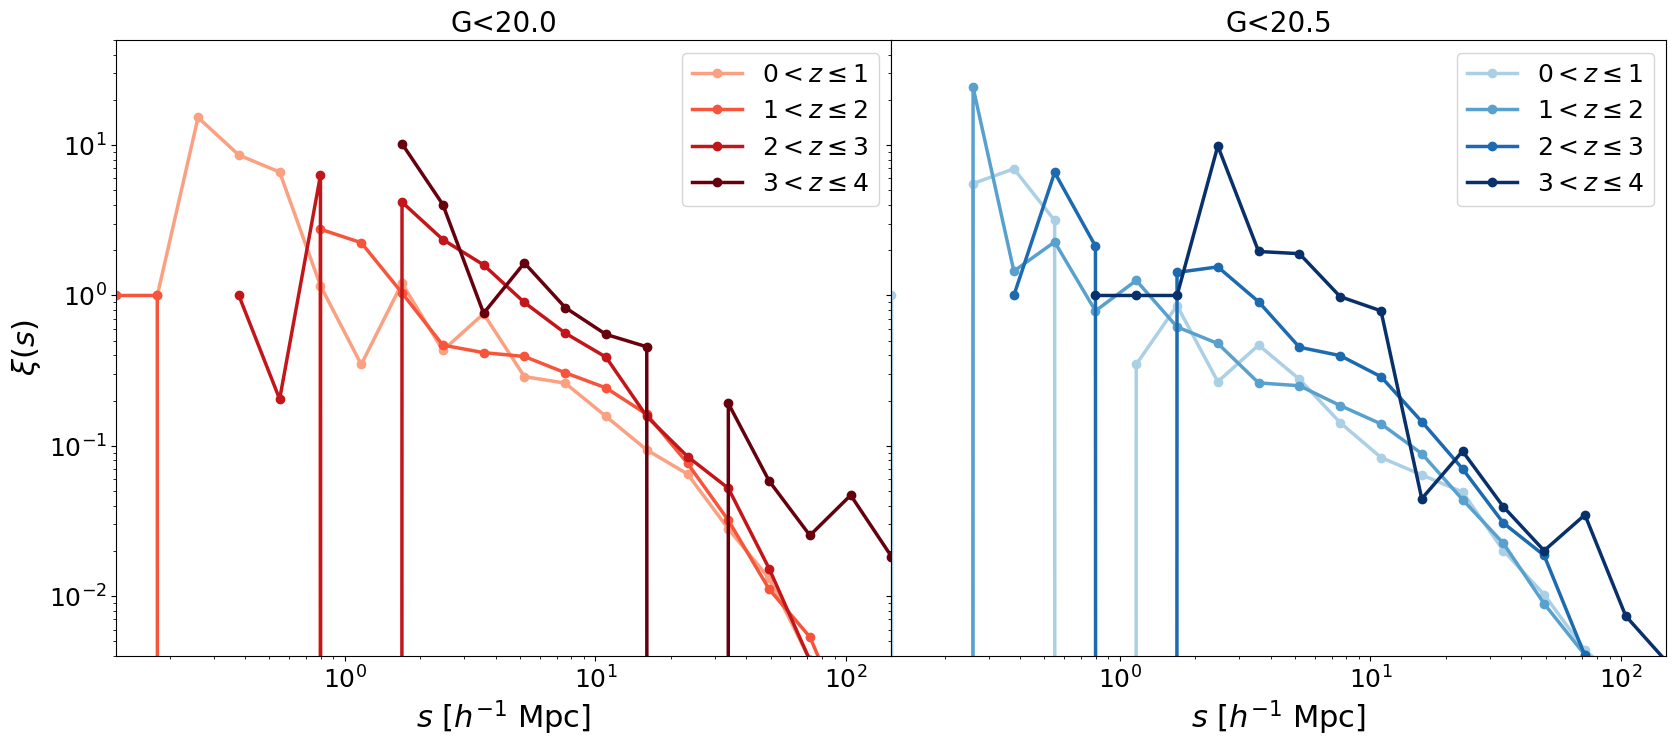

In [16]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

### All sky

_G20.0_zmin0.0zmax1.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin1.0zmax2.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin2.0zmax3.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_zmin3.0zmax4.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


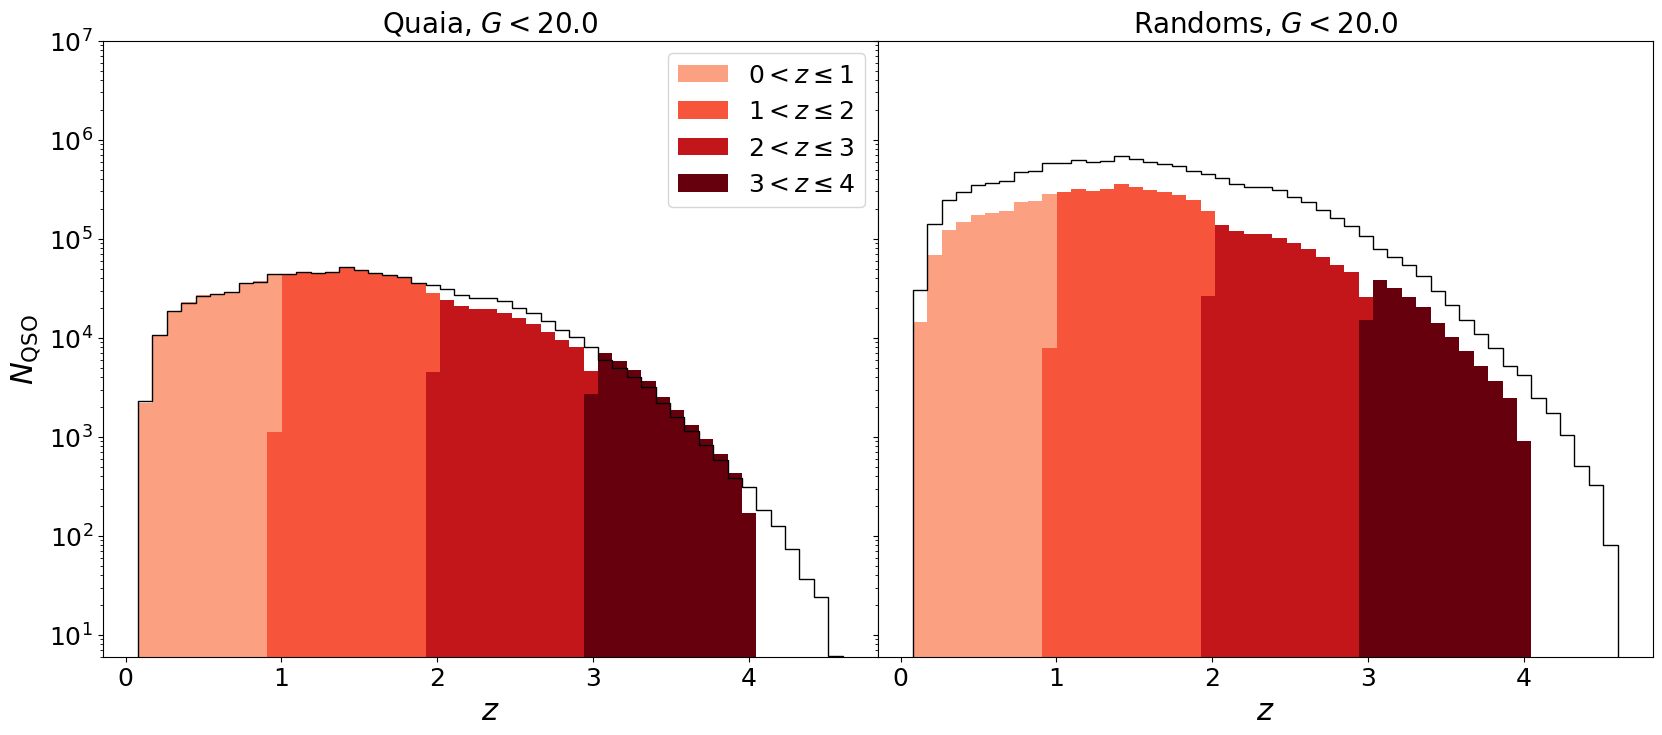

_G20.5_zmin0.0zmax1.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin1.0zmax2.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin2.0zmax3.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_zmin3.0zmax4.0
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


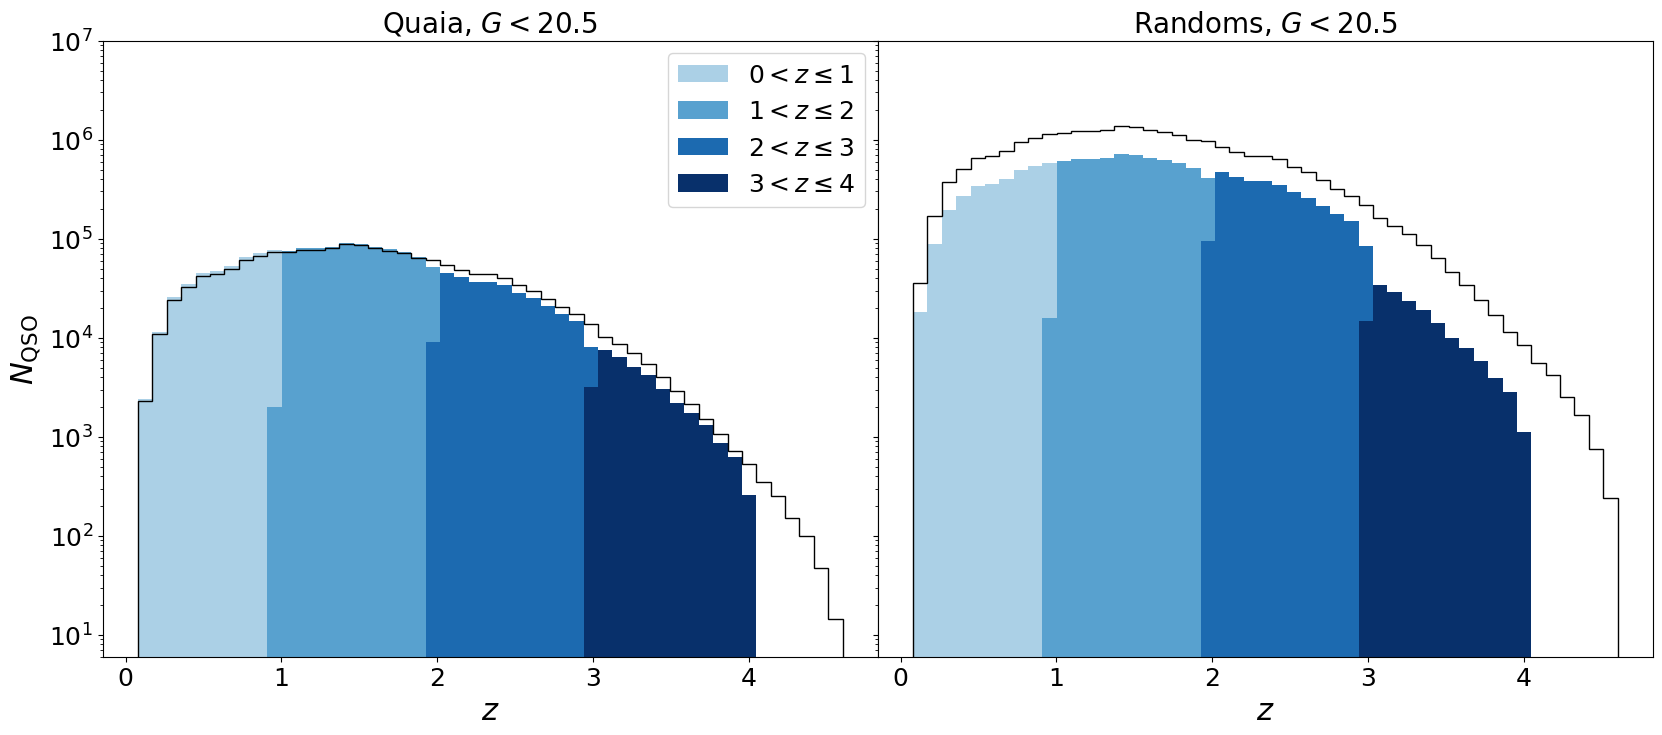

In [17]:
# plot data
bins = np.linspace(0.08, 4.6)
cf_allsky = {20.0: [], 20.5: []}
for G, cmap in zip(G_array, cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black', 
             weights = 1/selfunc_hi[pixel_indices_datahi][mask_datahi])

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_allsky_10x.fits'.format(G)
    tab_randhi = Table.read(fn_randhi)
    # pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    # mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    # N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_randhi = len(tab_randhi['ra'])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, np.full(N_randhi, True), N_datahi_mask, N_randhi, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins,
             color = 'black')

    for zbin in zbin_array[:-1]:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, weights1 = quaia.make_bins(G, int(zbin),True, 'z', z_bins = zbin_array,
                                                                                               tab_gcat_type = 'data', method = 'minmax', 
                                                                                               allsky = '_allsky')
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 bins = bins, color = cmap[int(zbin)], weights = weights1)
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
                 bins = bins, color = cmap[int(zbin)])
        
        cf_allsky[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                       weights1 = weights1))

    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,1e7)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend()

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,1e7)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

In [18]:
hist, bin_edges = np.histogram(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, weights = 1/selfunc_hi[pixel_indices_datahi][mask_datahi])

In [19]:
len(tab_randhi['redshift_quaia_'+mask_type])/np.sum(hist)

15.721851562360591

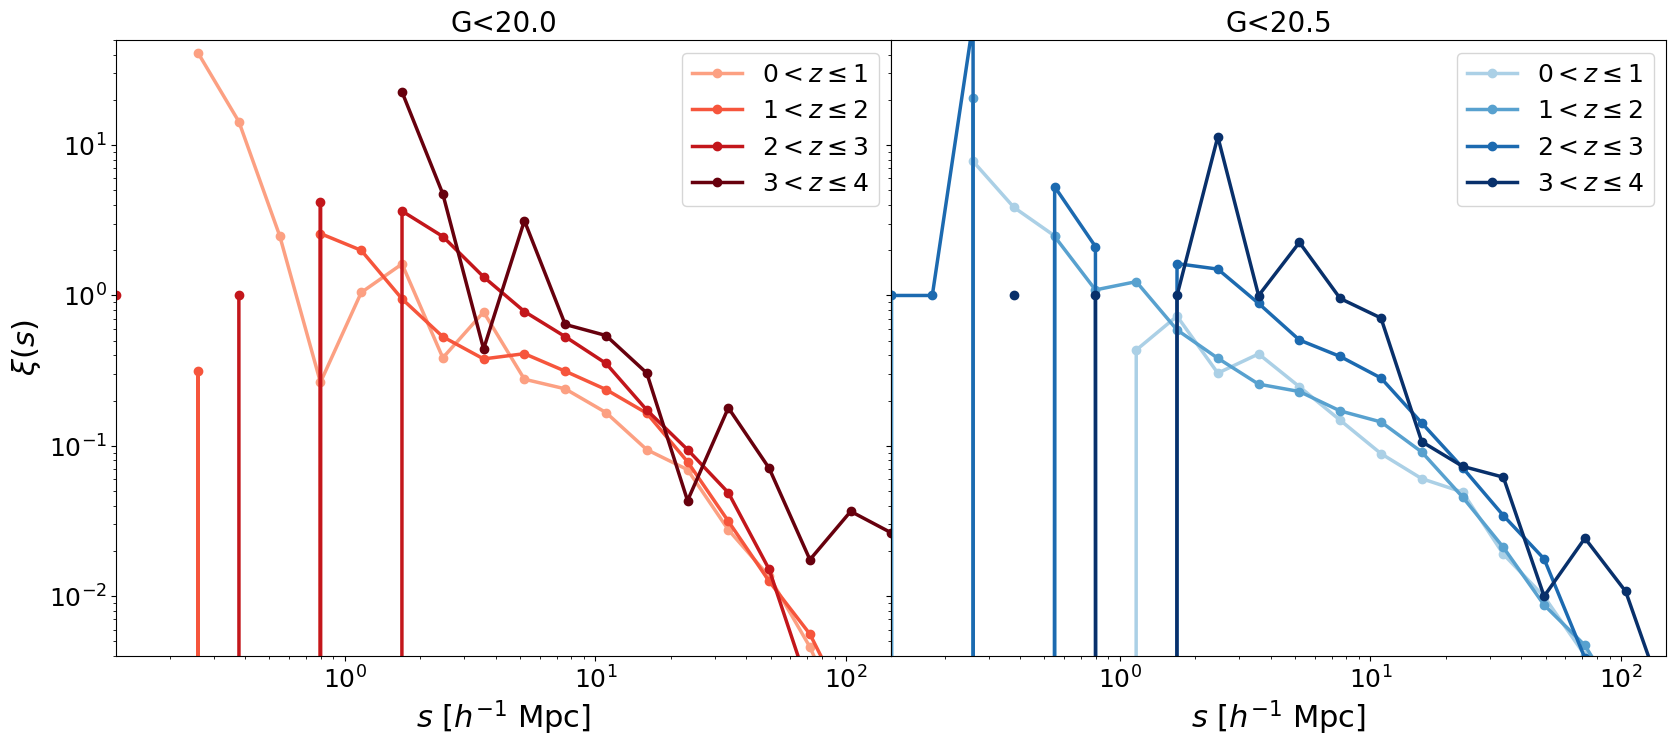

In [20]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf_allsky[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

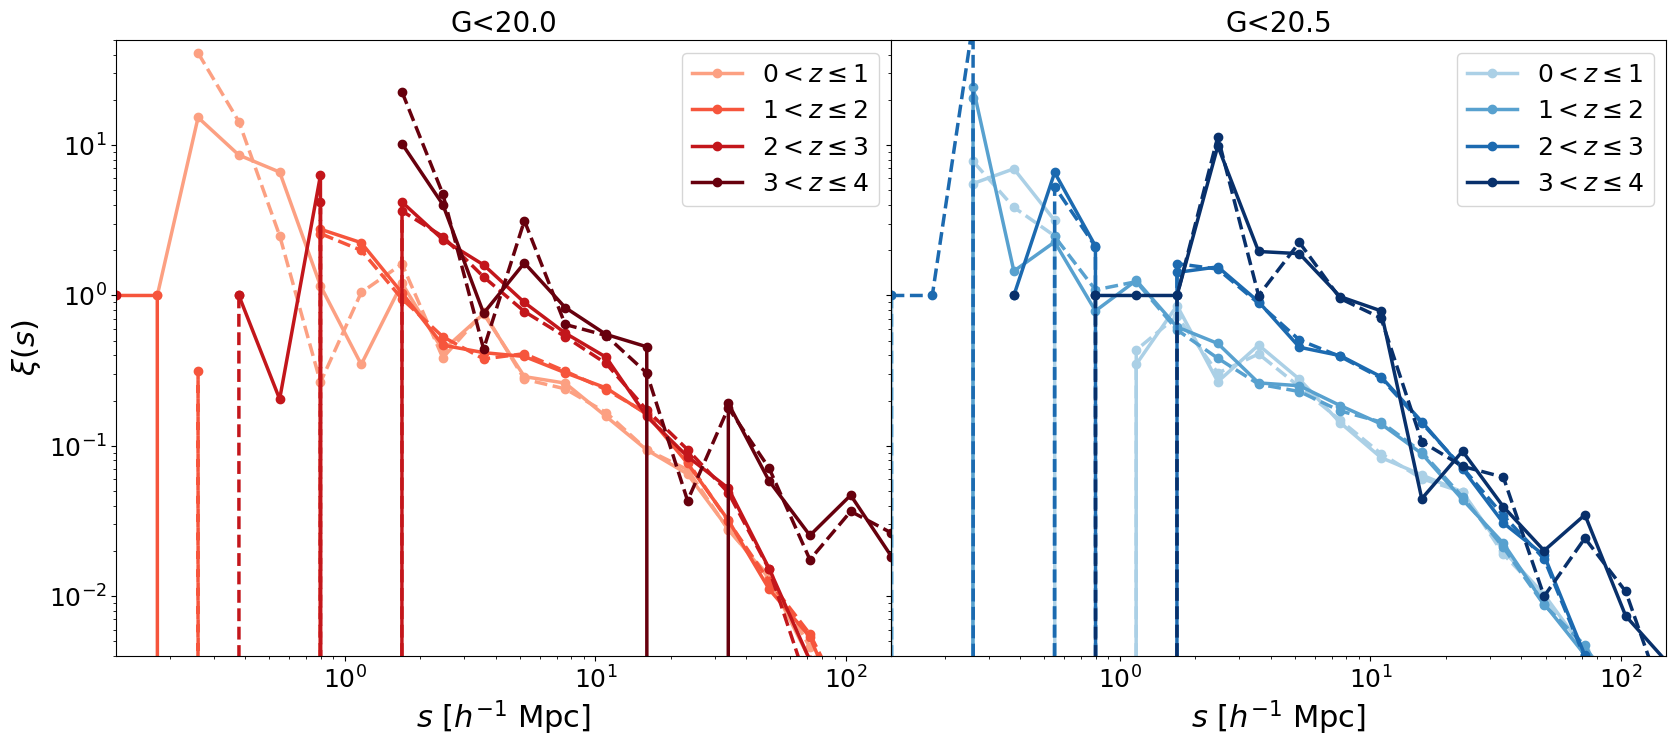

In [21]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array[:-1]:
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, color = cmaps[i][int(zbin)])
        ax1.plot(quaia.recenter(rbins), cf_allsky[G_array[i]][int(zbin)], marker = 'o', 
                 linewidth = 2.5, color = cmaps[i][int(zbin)], linestyle = '--')
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 26011014
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


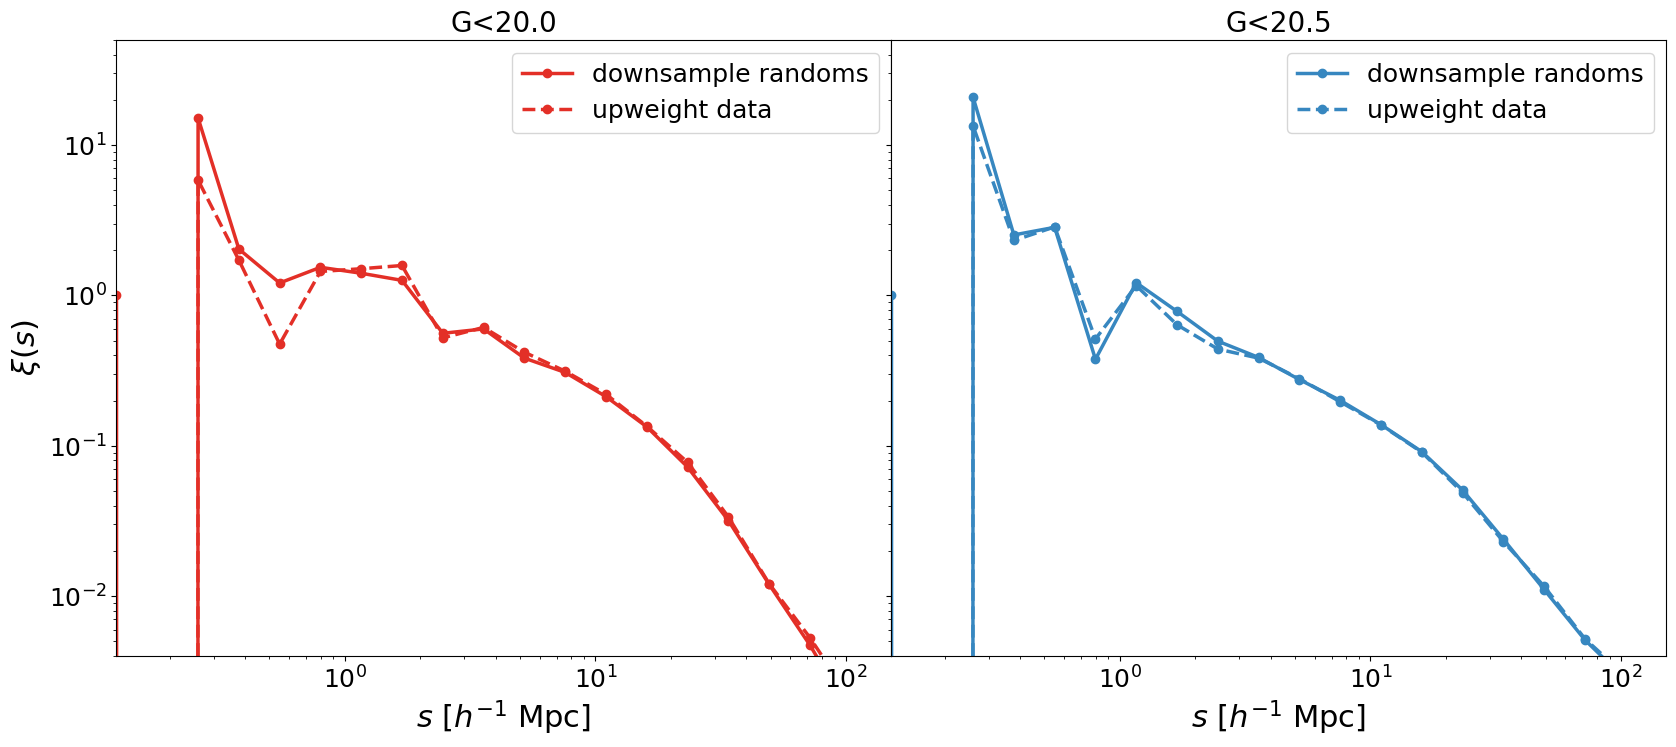

In [22]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
    
cf_test = {G_lo: [], G_hi: []}
cf_test_allsky = {G_lo: [], G_hi: []}
for G, ax, color in zip(G_array, gs, colors):
    
    ax1 = fig.add_subplot(ax)

    # for comparison purposes
    # fn_randhi = '../data/randoms/random_G{}_allsky_10x.fits'.format(G)
    # tab_randhi = Table.read(fn_randhi)
    # pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    
    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    # mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5    
    # N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    # N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    
    tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G), G, fn_selhi, 
                                                                                   mask_type = mask_type)

    # regular method
    tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_10x.fits'.format(G), G, fn_selhi, 
                                                                                     mask_type = mask_type)
    key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    cf_test[G] = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins)
    ax1.plot(quaia.recenter(rbins), cf_test[G], marker = 'o', label = 'downsample randoms', 
                 linewidth = 2.5, color = color)
    
    # upweighted method
    # N_randhi = len(tab_randhi['ra'])
    # _, pixel_indices_datahi, N_datahi, _ = quaia.read('../data/quaia_G{}.fits'.format(G), G, fn_selhi)
    (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
     mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_10x.fits'.format(G), G, fn_selhi, mask_type = mask_type)
    key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                              mask_type = 'allsky')
    cf_test_allsky[G] = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads, rbins = rbins, 
                                weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])  
    ax1.plot(quaia.recenter(rbins), cf_test_allsky[G], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = color, linestyle = '--')
    
    ax1.set_title('G<{}'.format(G))
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(4e-3, 5e1)
    ax1.legend()
    if G==G_lo:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

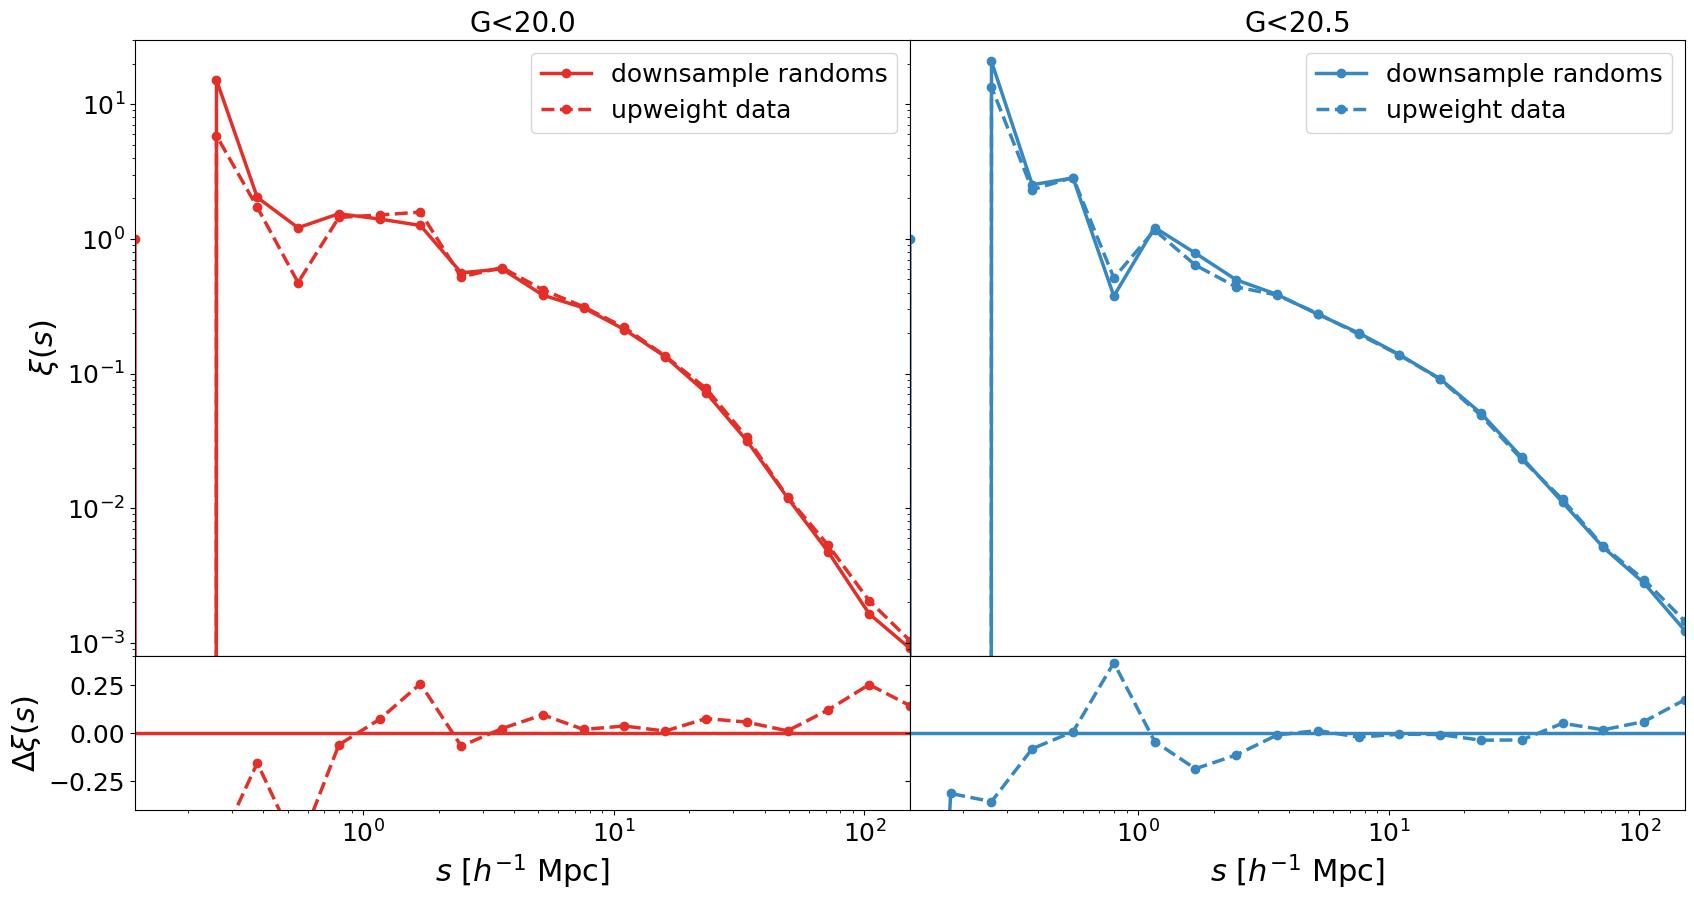

In [23]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

for i in range(len(colors)):
    
    ax1 = fig.add_subplot(gs[i])
    
#     fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
#     selfunc_hi = hp.fitsfunc.read_map(fn_selhi)
    
#     tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], fn_selhi, 
#                                                                                    mask_type = mask_type)

#     # regular method
#     tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_10x.fits'.format(G_array[i]), 
#                                                                                    G_array[i], fn_selhi, mask_type = mask_type)
#     key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
#     cf_test = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins)
    ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]], marker = 'o', label = 'downsample randoms', 
                 linewidth = 2.5, color = colors[i])
    
    # upweighted method
    # (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
    #  mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_10x.fits'.format(G_array[i]), G_array[i], fn_selhi, mask_type = mask_type)
    # key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
    #                           mask_type = 'allsky')
    # cf_test_allsky = quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads, rbins = rbins, 
    #                             weights1 = 1/selfunc_hi[pixel_indices_datahi_mask])  
    ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = colors[i], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))
    # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xticklabels([])
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(8e-4, 3e1)
    ax1.legend()
        
    ax2 = fig.add_subplot(gs[i+2])
    
    ax2.axhline(0, linewidth = 2.5, color = colors[i])
    ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]]-cf_test[G_array[i]])/cf_test[G_array[i]], marker = 'o', label = 'upweight data', 
                 linewidth = 2.5, color = colors[i], linestyle = '--')
    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(-0.4, 0.4)
    
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')
    
    if i == 0:
        ax1.set_ylabel(r"$\xi(s)$")
        ax2.set_ylabel(r"$\Delta\xi(s)$")
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

plt.show()

### Understand facrand

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 129616435
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


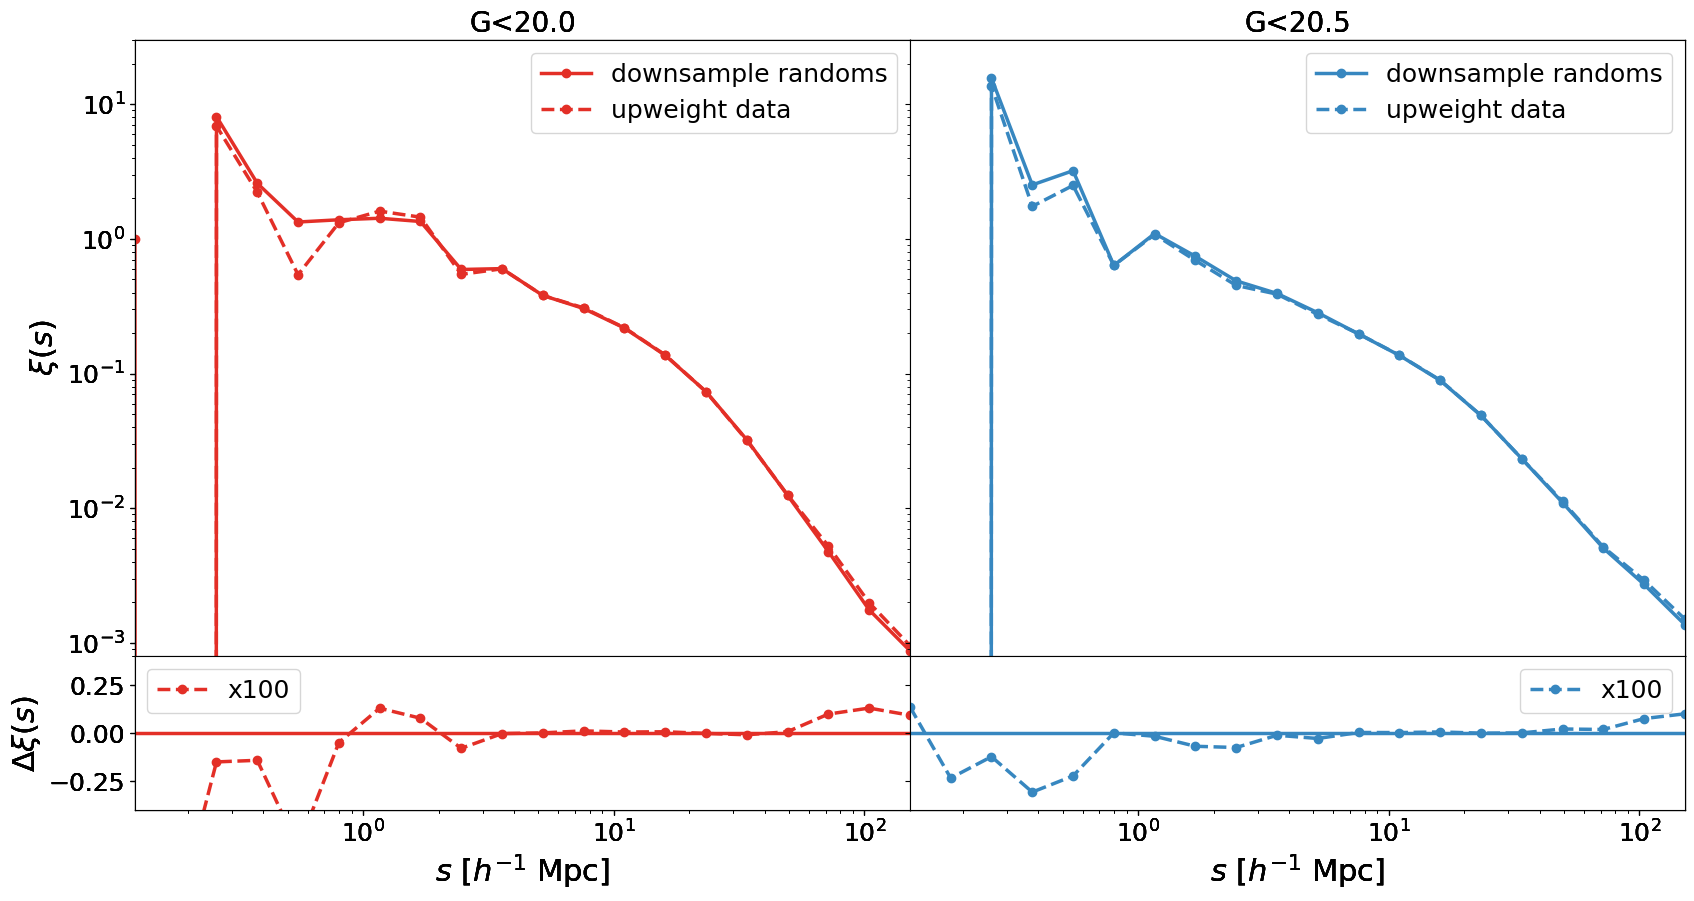

In [68]:
# plot!
# fig = plt.figure(figsize = (20, 10))
# gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

cf_test = {G_lo: [], G_hi: []}
cf_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):

        # ax1 = fig.add_subplot(gs[i])

        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        cf_test[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins))
        # ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
        #              linewidth = 2.5, color = colors[i])

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        cf_test_allsky[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads,
                                          rbins = rbins, weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))
#         ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
#                      linewidth = 2.5, color = colors[i], linestyle = '--')

#         ax1.set_title('G<{}'.format(G_array[i]))
#         # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
#         ax1.set_xticklabels([])
#         ax1.set_yscale('log')
#         ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax1.set_ylim(8e-4, 3e1)
#         ax1.legend()

#         ax2 = fig.add_subplot(gs[i+2])

#         ax2.axhline(0, linewidth = 2.5, color = colors[i])
#         ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
#                  label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = colors[i], linestyle = '--')
#         ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
#         ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax2.set_ylim(-0.4, 0.4)
#         ax2.legend()

#         if scale == 'log':
#             ax1.set_xscale('log')
#             ax2.set_xscale('log')

#         if i == 0:
#             ax1.set_ylabel(r"$\xi(s)$")
#             ax2.set_ylabel(r"$\Delta\xi(s)$")
#         else:
#             ax1.set_yticklabels([])
#             ax2.set_yticklabels([])

# plt.show()

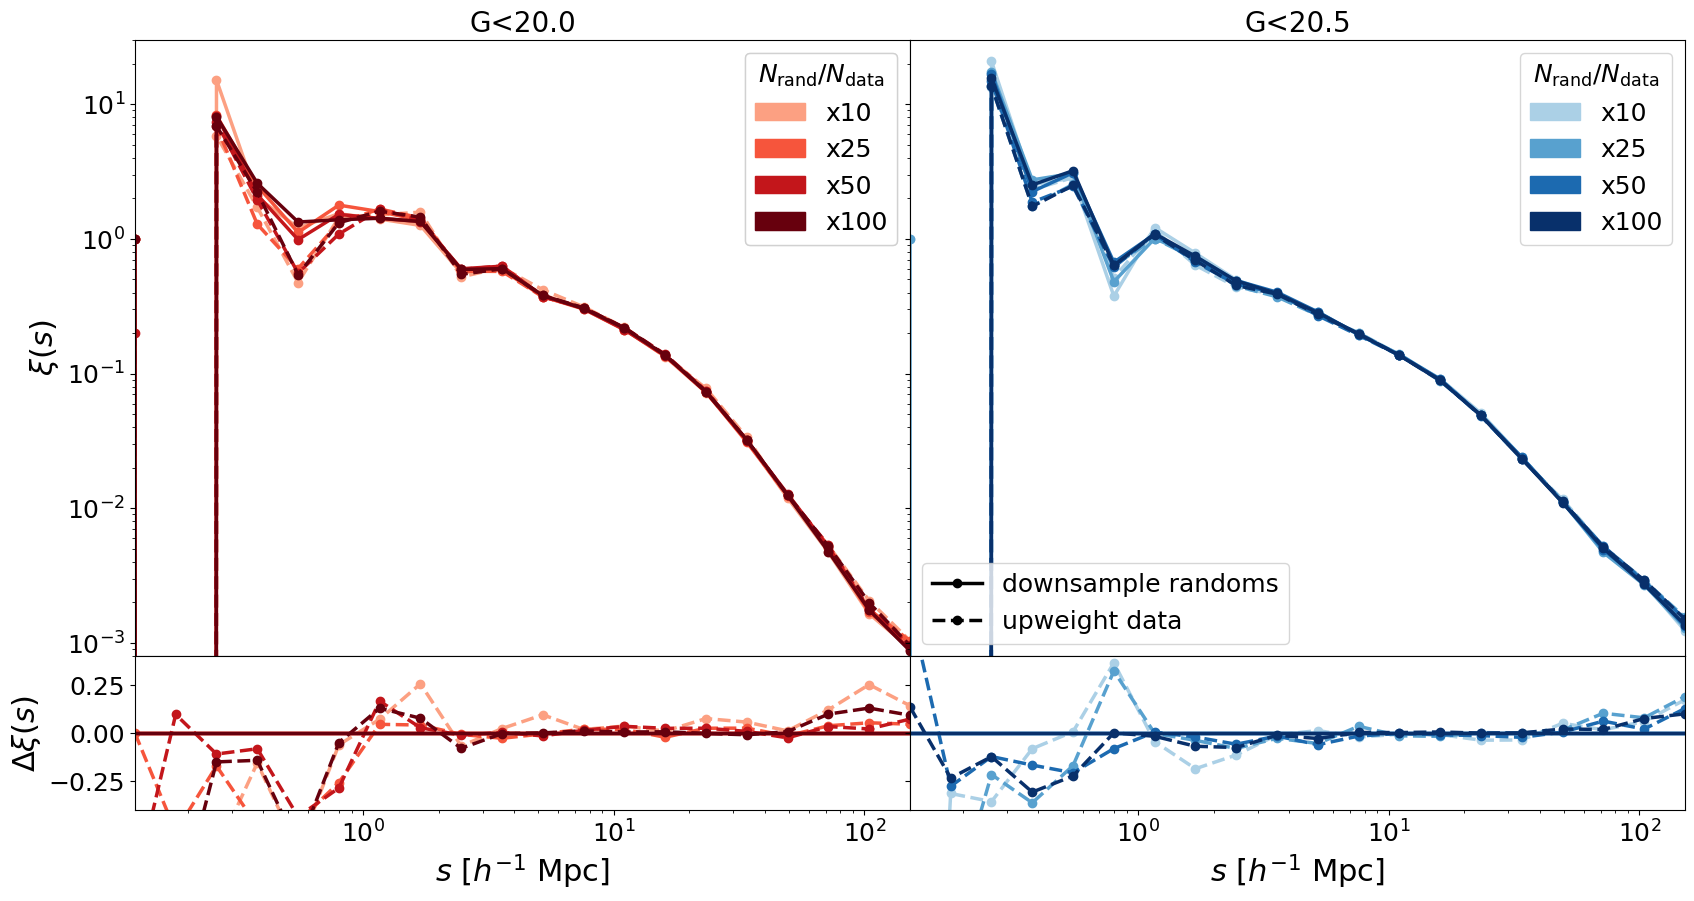

In [111]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)

# cf_test = {G_lo: [], G_hi: []}
# cf_test_allsky = {G_lo: [], G_hi: []}
# facrand = [10, 25, 50, 100]
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

#         fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
#         selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

#         tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
#                                                                                        fn_selhi, mask_type = mask_type)

#         # regular method
#         tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
#                                                                                                                                     facrand[j]), 
#                                                                                        G_array[i], fn_selhi, mask_type = mask_type)
#         key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
#         cf_test[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins))
        ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        # (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
        #  mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
        #                                   mask_type = mask_type)
        # key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
        #                           mask_type = 'allsky')
        # cf_test_allsky[G_array[i]].append(quaia.xi_s(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, nthreads = nthreads,
        #                                   rbins = rbins, weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))
        ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        # ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(8e-4, 3e1)
        # ax1.legend()

        # print('x{}'.format(facrand[j]))
        # print('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]))
        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        # j=0
        ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)
        # ax2.legend()

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$\xi(s)$")
            ax2.set_ylabel(r"$\Delta\xi(s)$")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

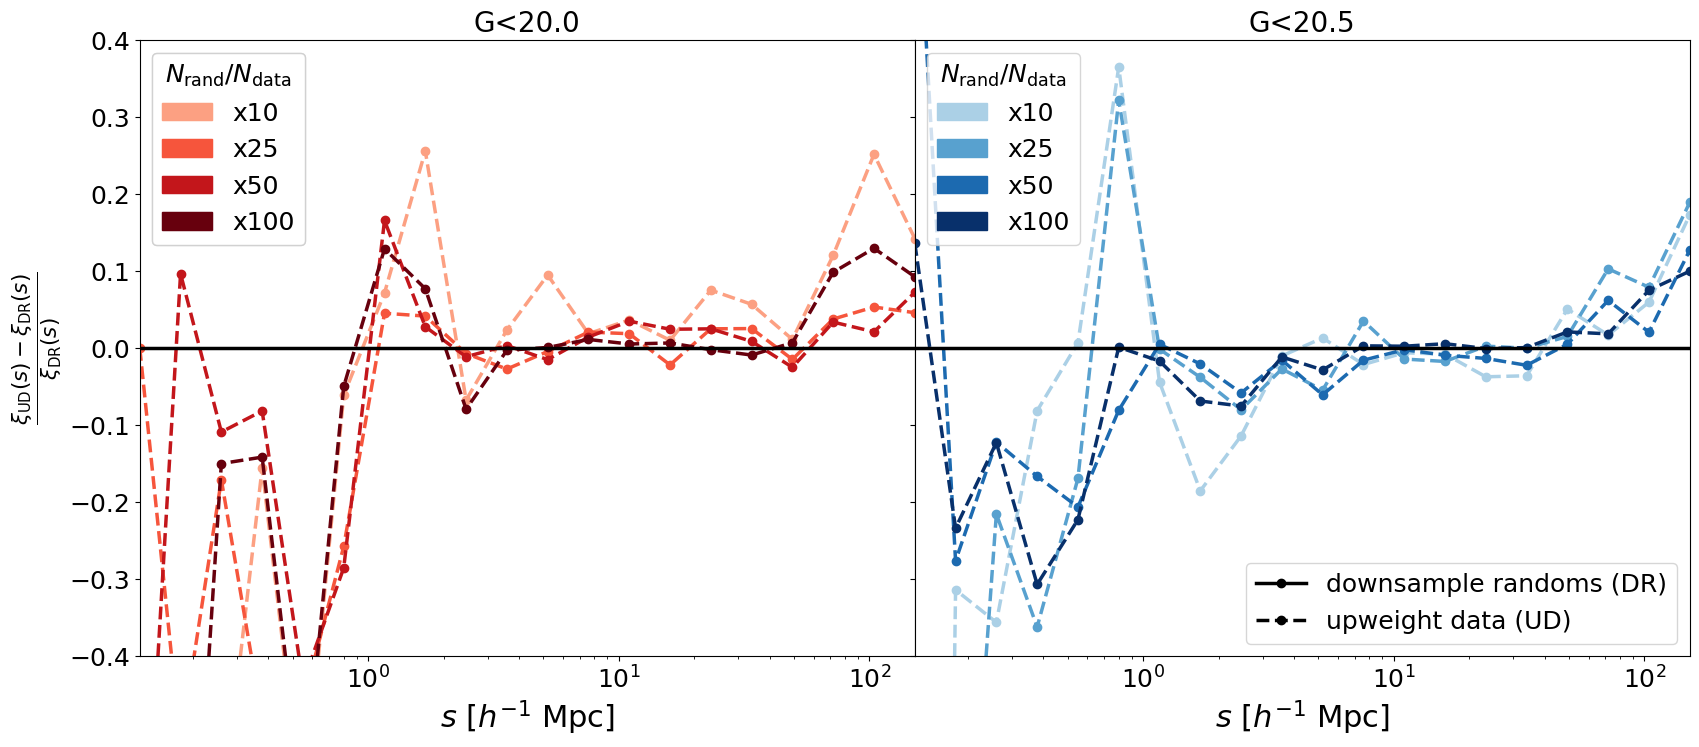

In [118]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(len(facrand)):

#         # regular method
#         ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
#                      linewidth = 2.5, color = colors[i])

#         # upweighted method
#         ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
#                      linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        
#         ax1.set_xticklabels([])
#         ax1.set_yscale('log')
#         ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
#         ax1.set_ylim(8e-4, 3e1)

        ax1.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
    
    ax1.set_title('G<{}'.format(G_array[i]))    
    ax1.axhline(0, linewidth = 2.5,color = 'black')
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(-0.4, 0.4)

    if scale == 'log':
        ax1.set_xscale('log')
        # ax2.set_xscale('log')

    if i == 0:
        # ax1.set_ylabel(r"$\xi(s)$")
        ax1.set_ylabel(r"$\frac{\xi_\mathrm{UD}(s)-\xi_\mathrm{DR}(s)}{\xi_\mathrm{DR}(s)}$")
    else:
        ax1.set_yticklabels([])
        # ax2.set_yticklabels([])

    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper left', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)
    
custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms (DR)', 'upweight data (UD)'], loc = 'lower right')

plt.show()

In [29]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [31]:
pimax = 80 # 40 # 5000.0 # 40.0

In [33]:
import importlib
importlib.reload(quaia)

<module 'quaia' from '/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py'>

In [ ]:
wp_test = {G_lo: [], G_hi: []}
wp_test_allsky = {G_lo: [], G_hi: []}
facrand = [10, 25, 50, 100]
for j in range(len(facrand)):
    
    for i in range(len(colors)):


        fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
        selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

        tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read('../data/quaia_G{}.fits'.format(G_array[i]), G_array[i], 
                                                                                       fn_selhi, mask_type = mask_type)

        # regular method
        tab_randhi, pixel_indices_randhi_mask, N_randhi_mask, mask_randhi = quaia.read('../data/randoms/random_G{}_{}x.fits'.format(G_array[i], 
                                                                                                                                    facrand[j]), 
                                                                                       G_array[i], fn_selhi, mask_type = mask_type)
        key = quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
        wp_test[G_array[i]].append(quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi[mask_randhi], key, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax))

        # upweighted method
        (tab_randhi_allsky, pixel_indices_randhi_mask_allsky, N_randhi_mask_allsky, 
         mask_randhi_allsky) = quaia.read('../data/randoms/random_G{}_allsky_{}x.fits'.format(G_array[i], facrand[j]), G_array[i], fn_selhi, 
                                          mask_type = mask_type)
        key_allsky = quaia.z_dist(tab_datahi, tab_randhi_allsky,  mask_datahi, mask_randhi_allsky, N_datahi_mask, N_randhi_mask_allsky, 
                                  mask_type = 'allsky')
        wp_test_allsky[G_array[i]].append(quaia.wp_rp(tab_datahi[mask_datahi], tab_randhi_allsky[mask_randhi_allsky], key_allsky, 
                                                      nthreads = nthreads, rbins = rbins, nbins = nbins, pimax = pimax, 
                                                      weights1 = 1/selfunc_hi[pixel_indices_datahi_mask]))

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 7563151
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 12904608
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:927: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 12955802
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:927: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
Number of data sources: 75579272
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 129046081
OrderedDict()
Column names: <TableColumns names=('ra','dec','ebv')>
weighting DR
weighting DD


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [ ]:
# plot!
fig = plt.figure(figsize = (20, 10))
gs = gridspec.GridSpec(2, 2, wspace = 0, height_ratios = [4,1], hspace = 0)
    
for i in range(len(colors)):

    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])
    
    for j in range(len(facrand)):

        ax1.plot(quaia.recenter(rbins), cf_test[G_array[i]][j], marker = 'o', label = 'downsample randoms', 
                     linewidth = 2.5, color = cmaps[i][j])

        # upweighted method
        ax1.plot(quaia.recenter(rbins), cf_test_allsky[G_array[i]][j], marker = 'o', label = 'upweight data', 
                     linewidth = 2.5, color = cmaps[i][j], linestyle = '--')

        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xticklabels([])
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(8e-4, 3e1)

        ax2.axhline(0, linewidth = 2.5,color = cmaps[i][j])
        ax2.plot(quaia.recenter(rbins), (cf_test_allsky[G_array[i]][j]-cf_test[G_array[i]][j])/cf_test[G_array[i]][j], marker = 'o', 
                 label = 'x{}'.format(facrand[j]), linewidth = 2.5, color = cmaps[i][j], linestyle = '--')
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(-0.4, 0.4)

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if i == 0:
            ax1.set_ylabel(r"$\xi(s)$")
            ax2.set_ylabel(r"$\Delta\xi(s)$")
        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])
            
    patch = [mpatches.Patch(color=cmaps[i][k], label='x{}'.format(facrand[k])) for k in range(len(cmaps[i]))]
    first_legend = ax1.legend(handles=patch, loc = 'upper right', title = "$N_\mathrm{rand}/N_\mathrm{data}$", title_fontsize = 18)
    ax1.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '-', marker = 'o'), 
                Line2D([0], [0], color = 'black', linewidth = 2.5, linestyle = '--', marker = 'o')]
ax1.legend(custom_lines, ['downsample randoms', 'upweight data'], loc = 'lower left')

plt.show()

### Understand fraction of sources excluded

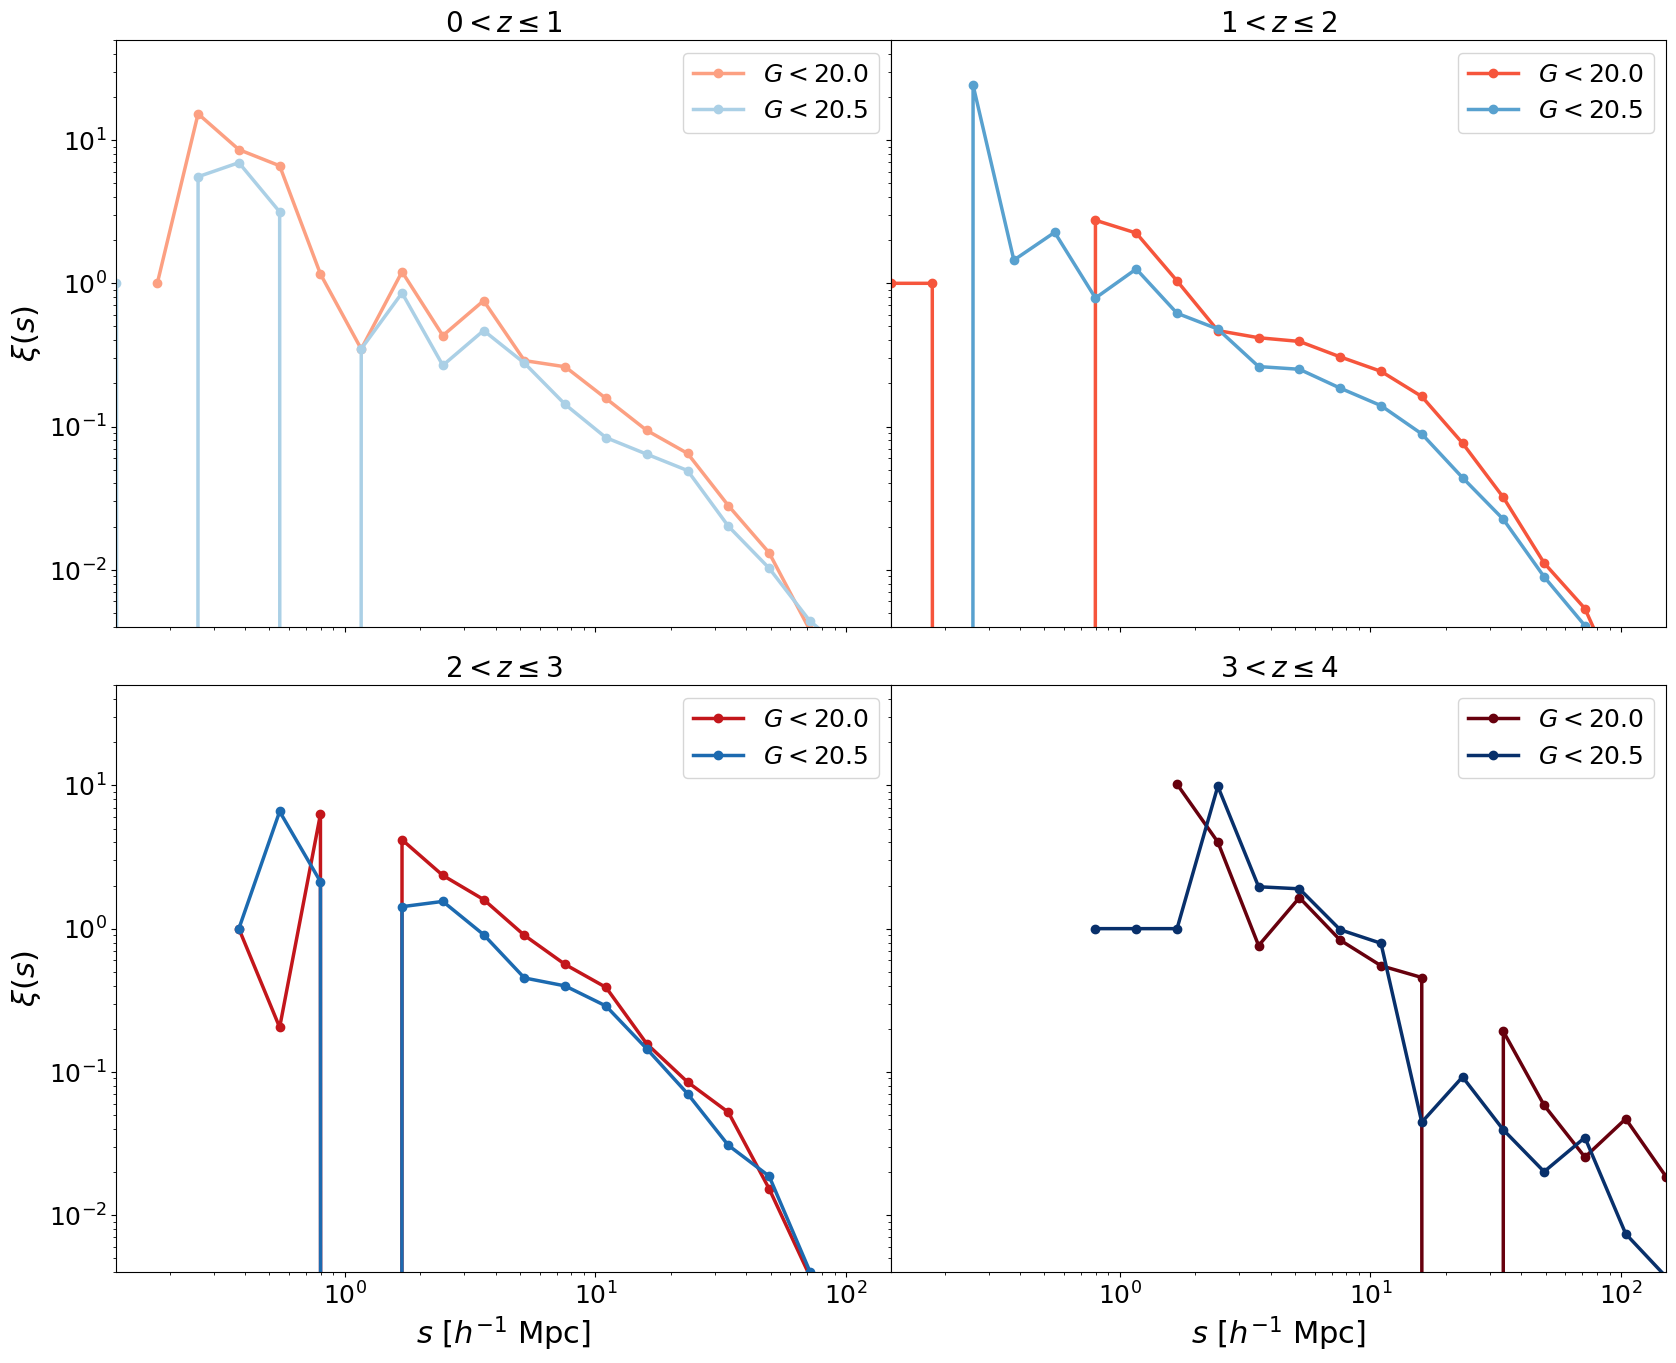

In [52]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(quaia.recenter(rbins), cf[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        if zbin>1:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        # if zbin==0:
        ax1.legend()

plt.show()

## $w_p(r_p)$

In [53]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [54]:
pimax = 80 # 40 # 5000.0 # 40.0

In [64]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, None, 
                                                                                                                  zbin)
        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

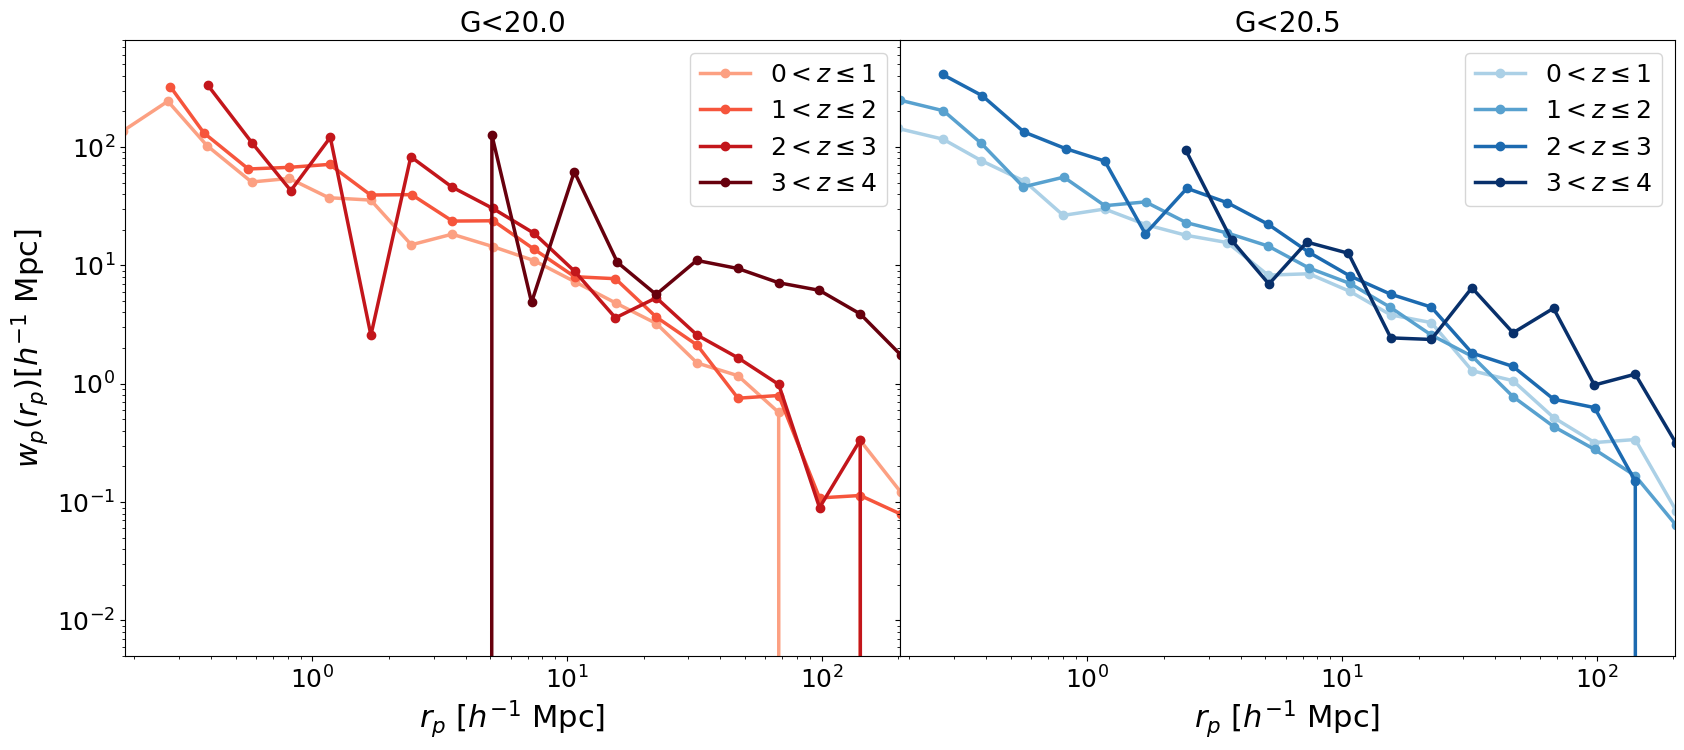

In [80]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

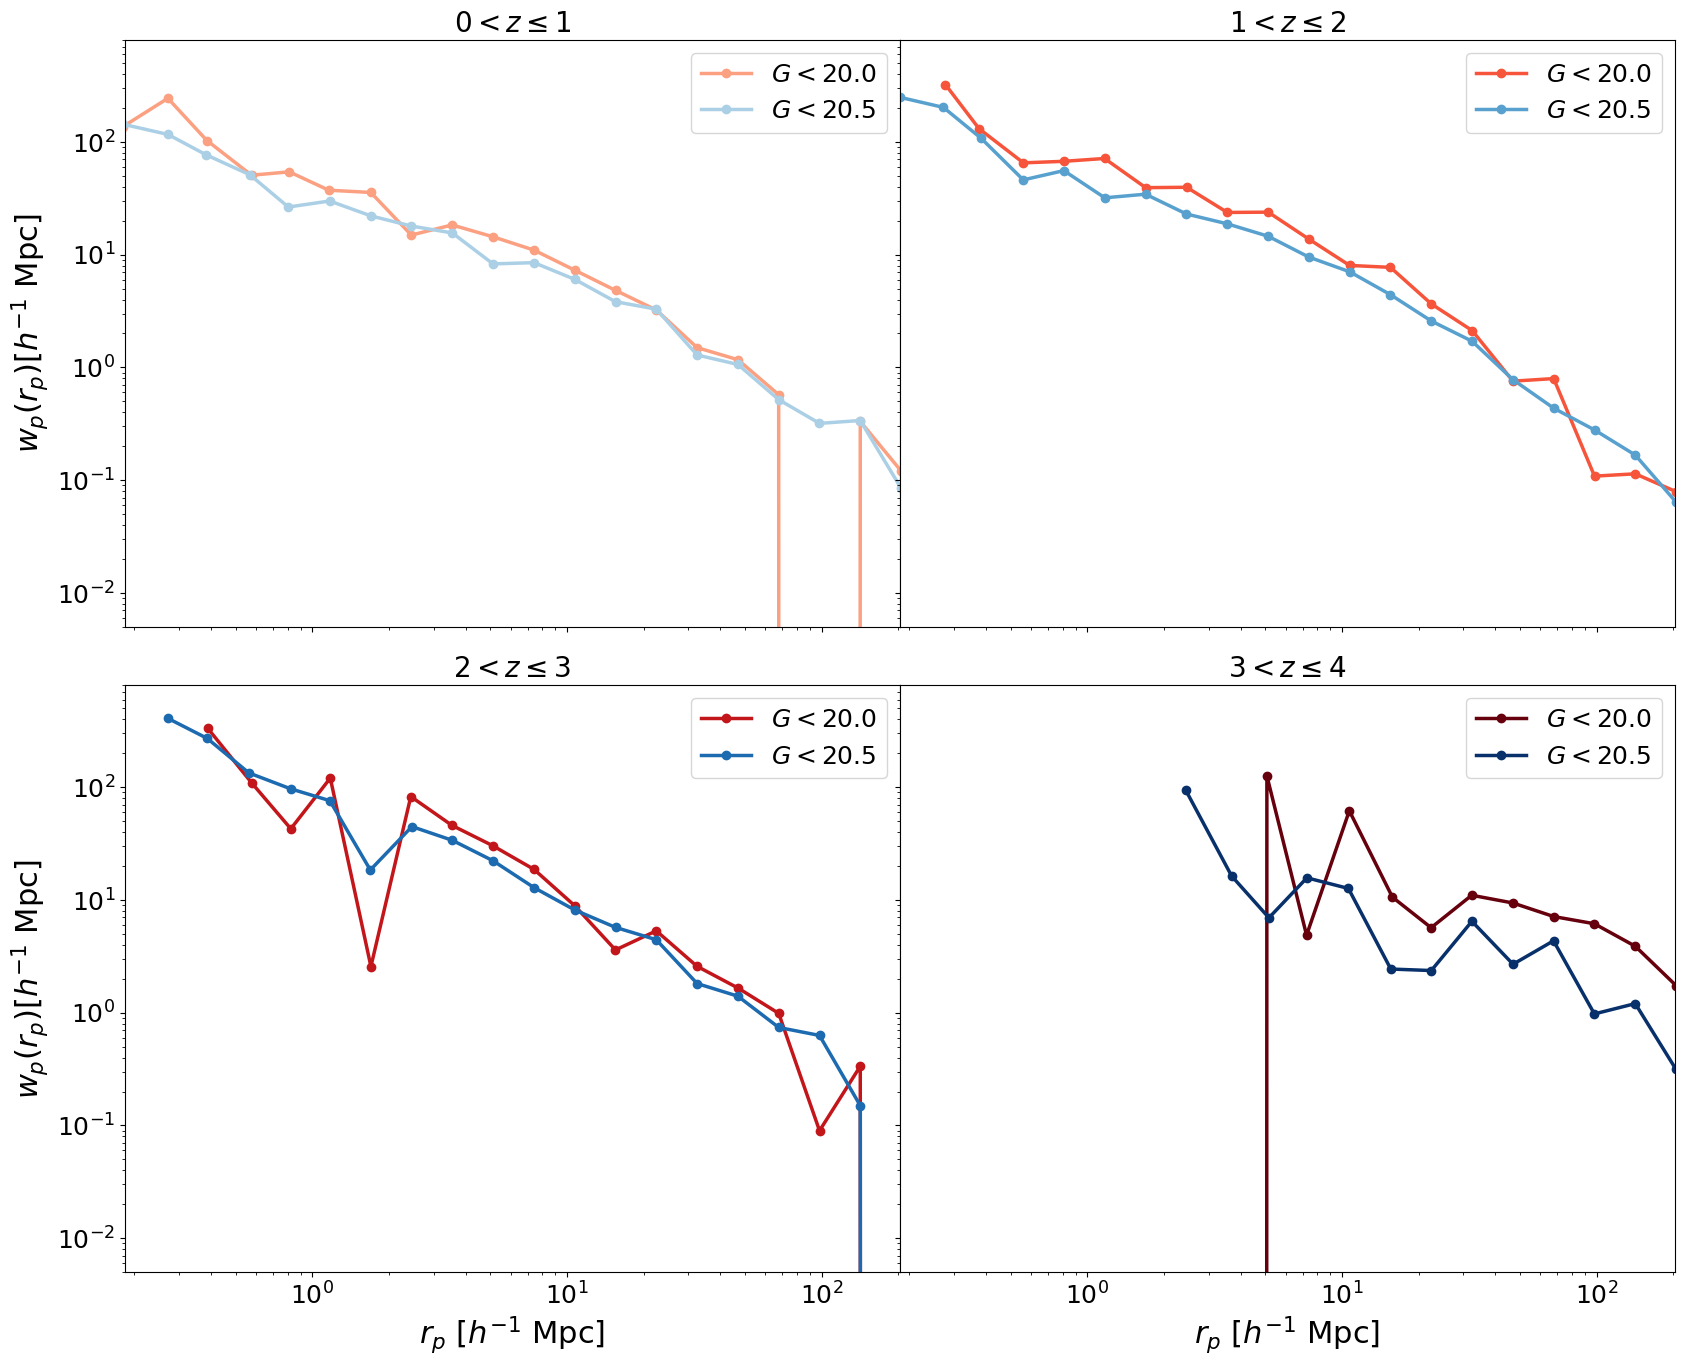

In [81]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(rpavg[G][zbin], wp[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

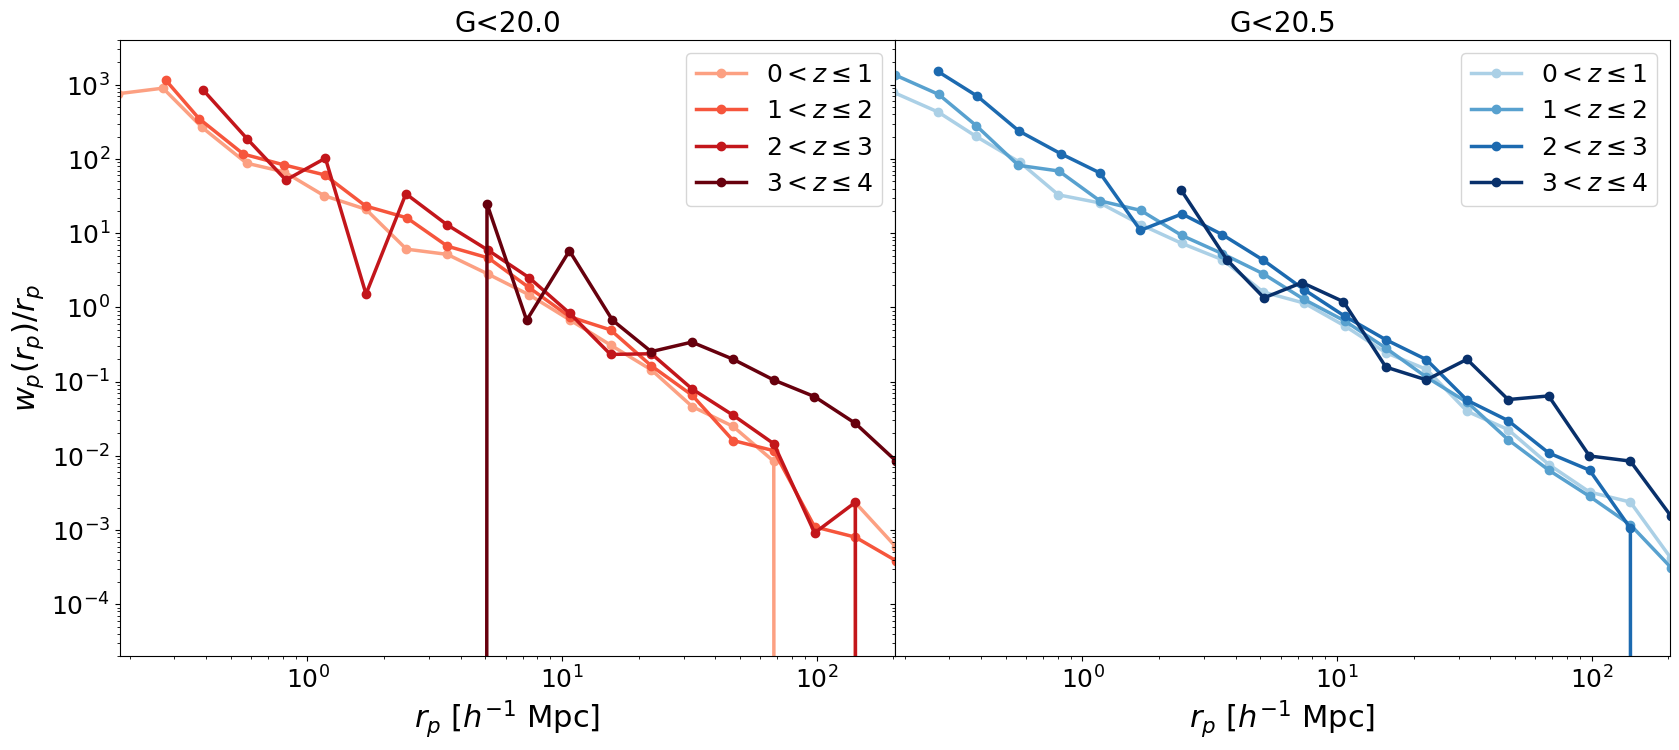

In [82]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
# i = 0
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin]/rpavg[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('G<{}'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-5, 4e3)
        ax1.legend()
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

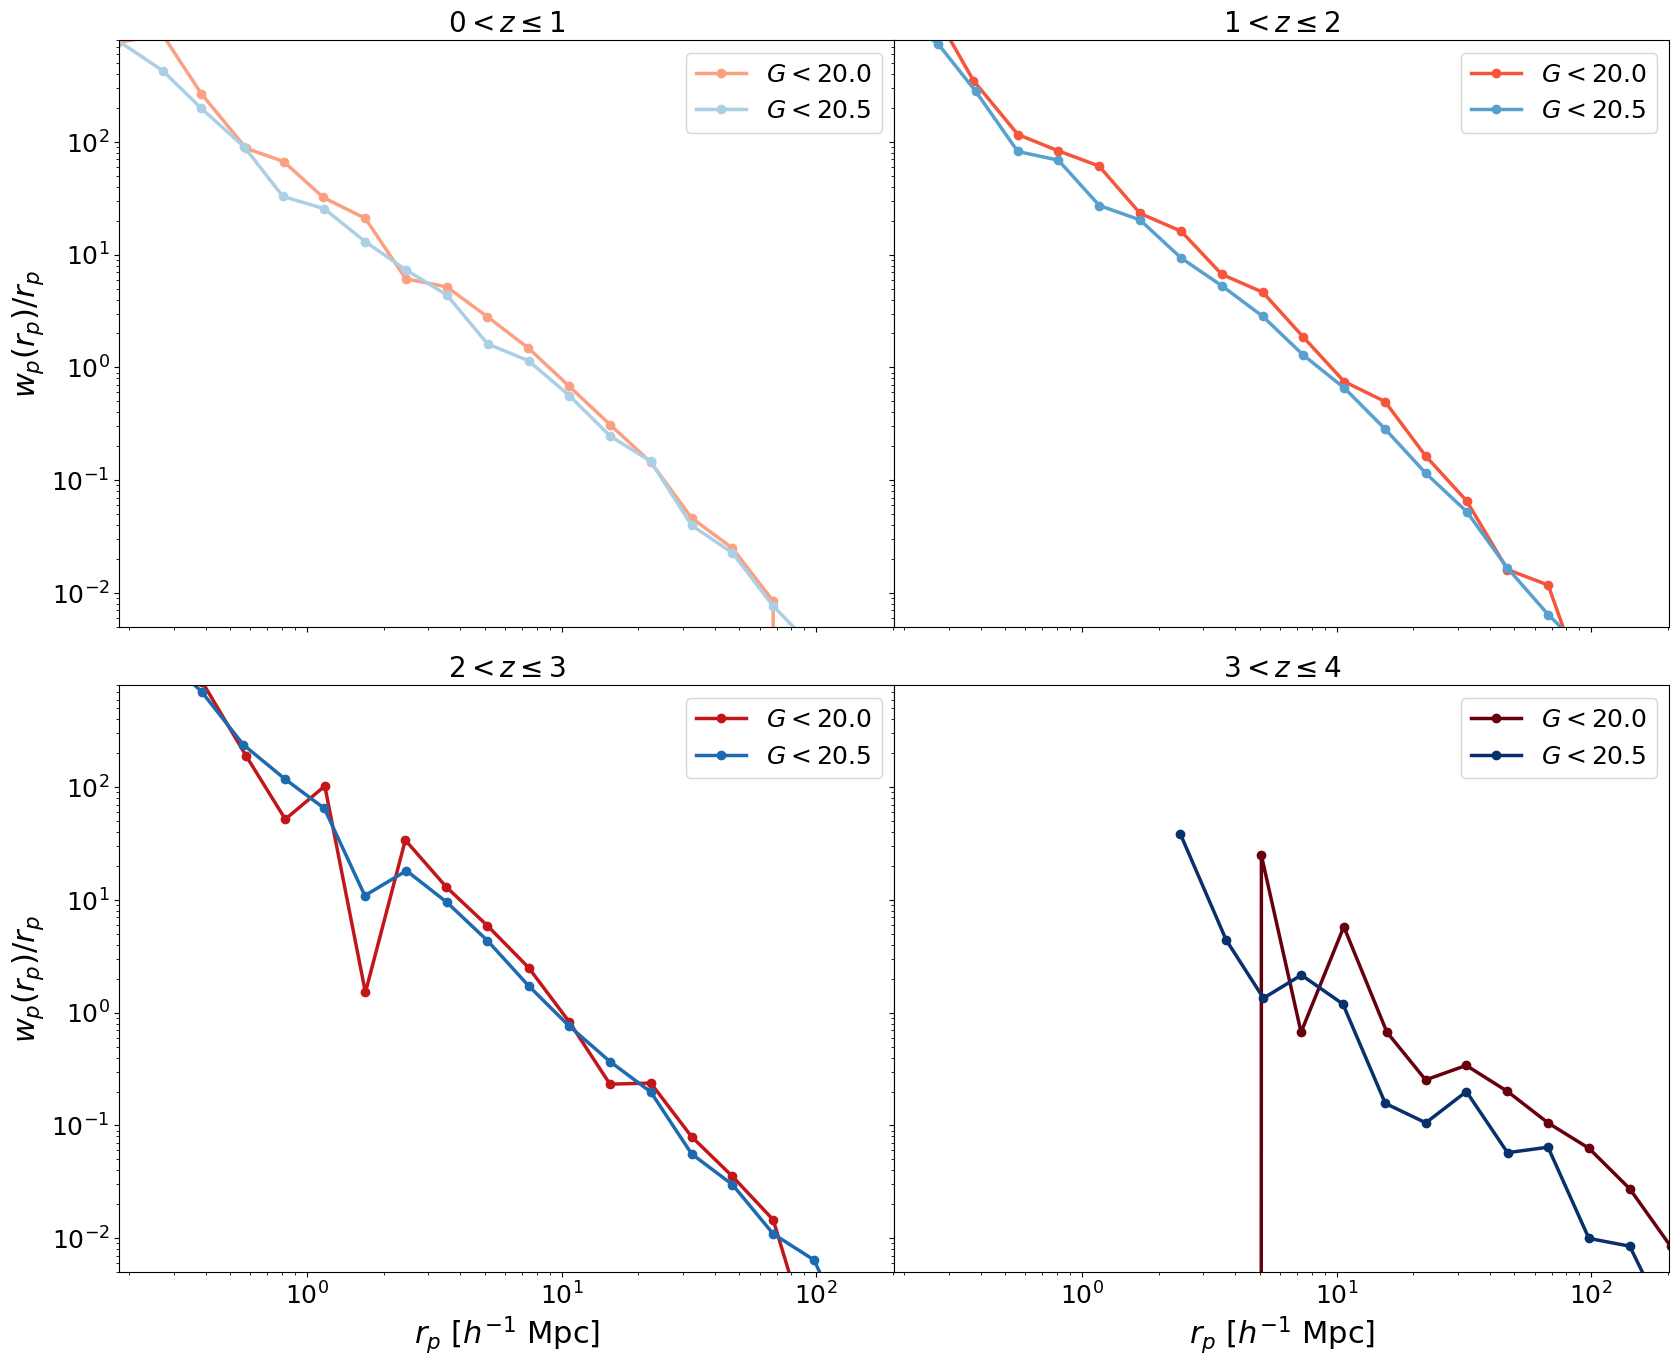

In [91]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:
        ax1.plot(rpavg[G][zbin], wp[G][zbin]/rpavg[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend()
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

## $w(\theta)$

In [83]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [84]:
# plot data
wtheta = {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, None, 
                                                                                                                  zbin)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

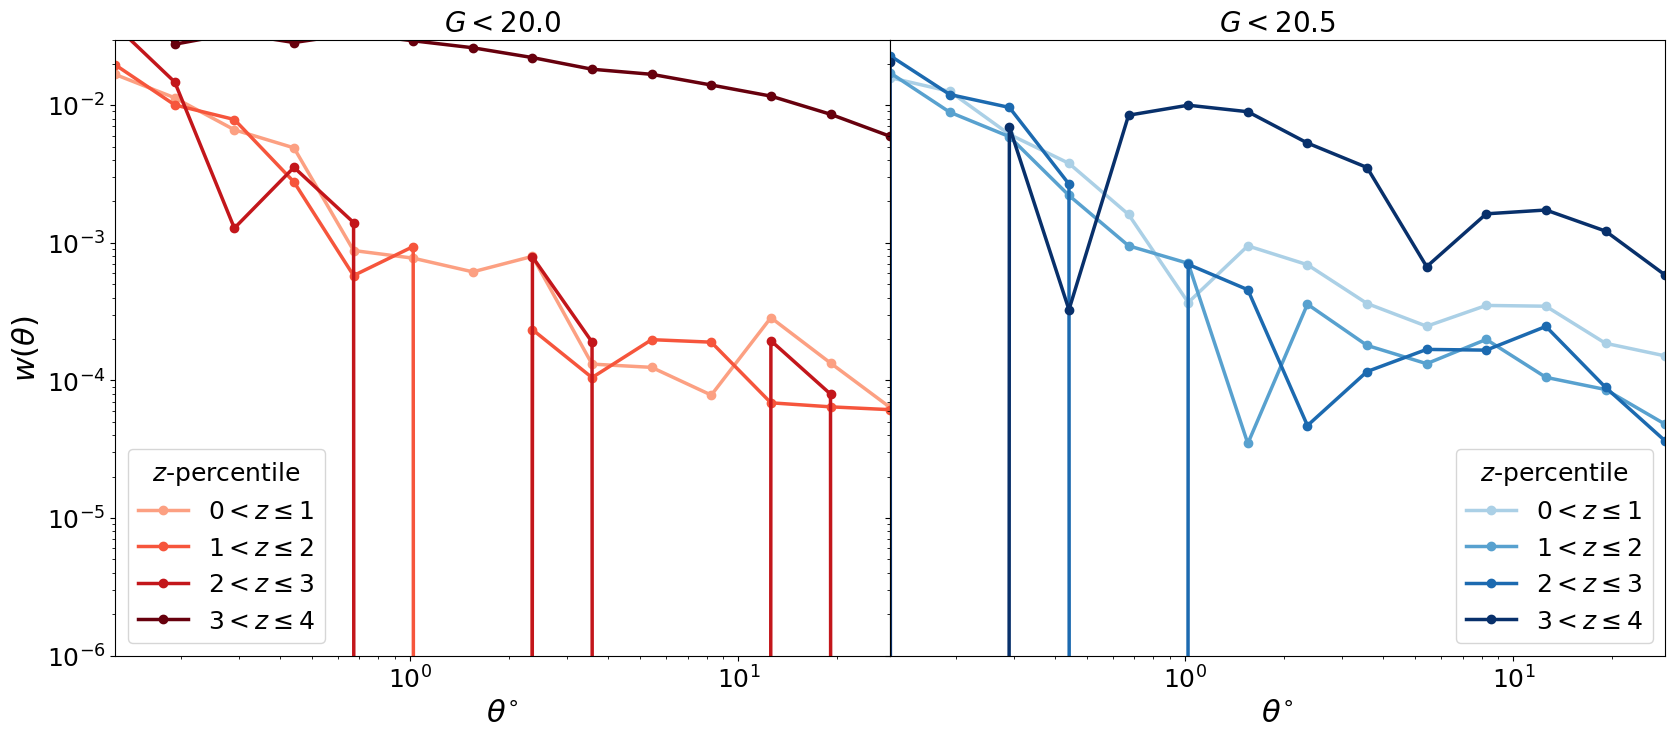

In [85]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][zbin], label = '${}<z \leq{}$'.format(zbin, zbin+1), 
                 linewidth = 2.5, marker = 'o', color = cmaps[G_array[i]][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$\theta^{\circ}$')
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()

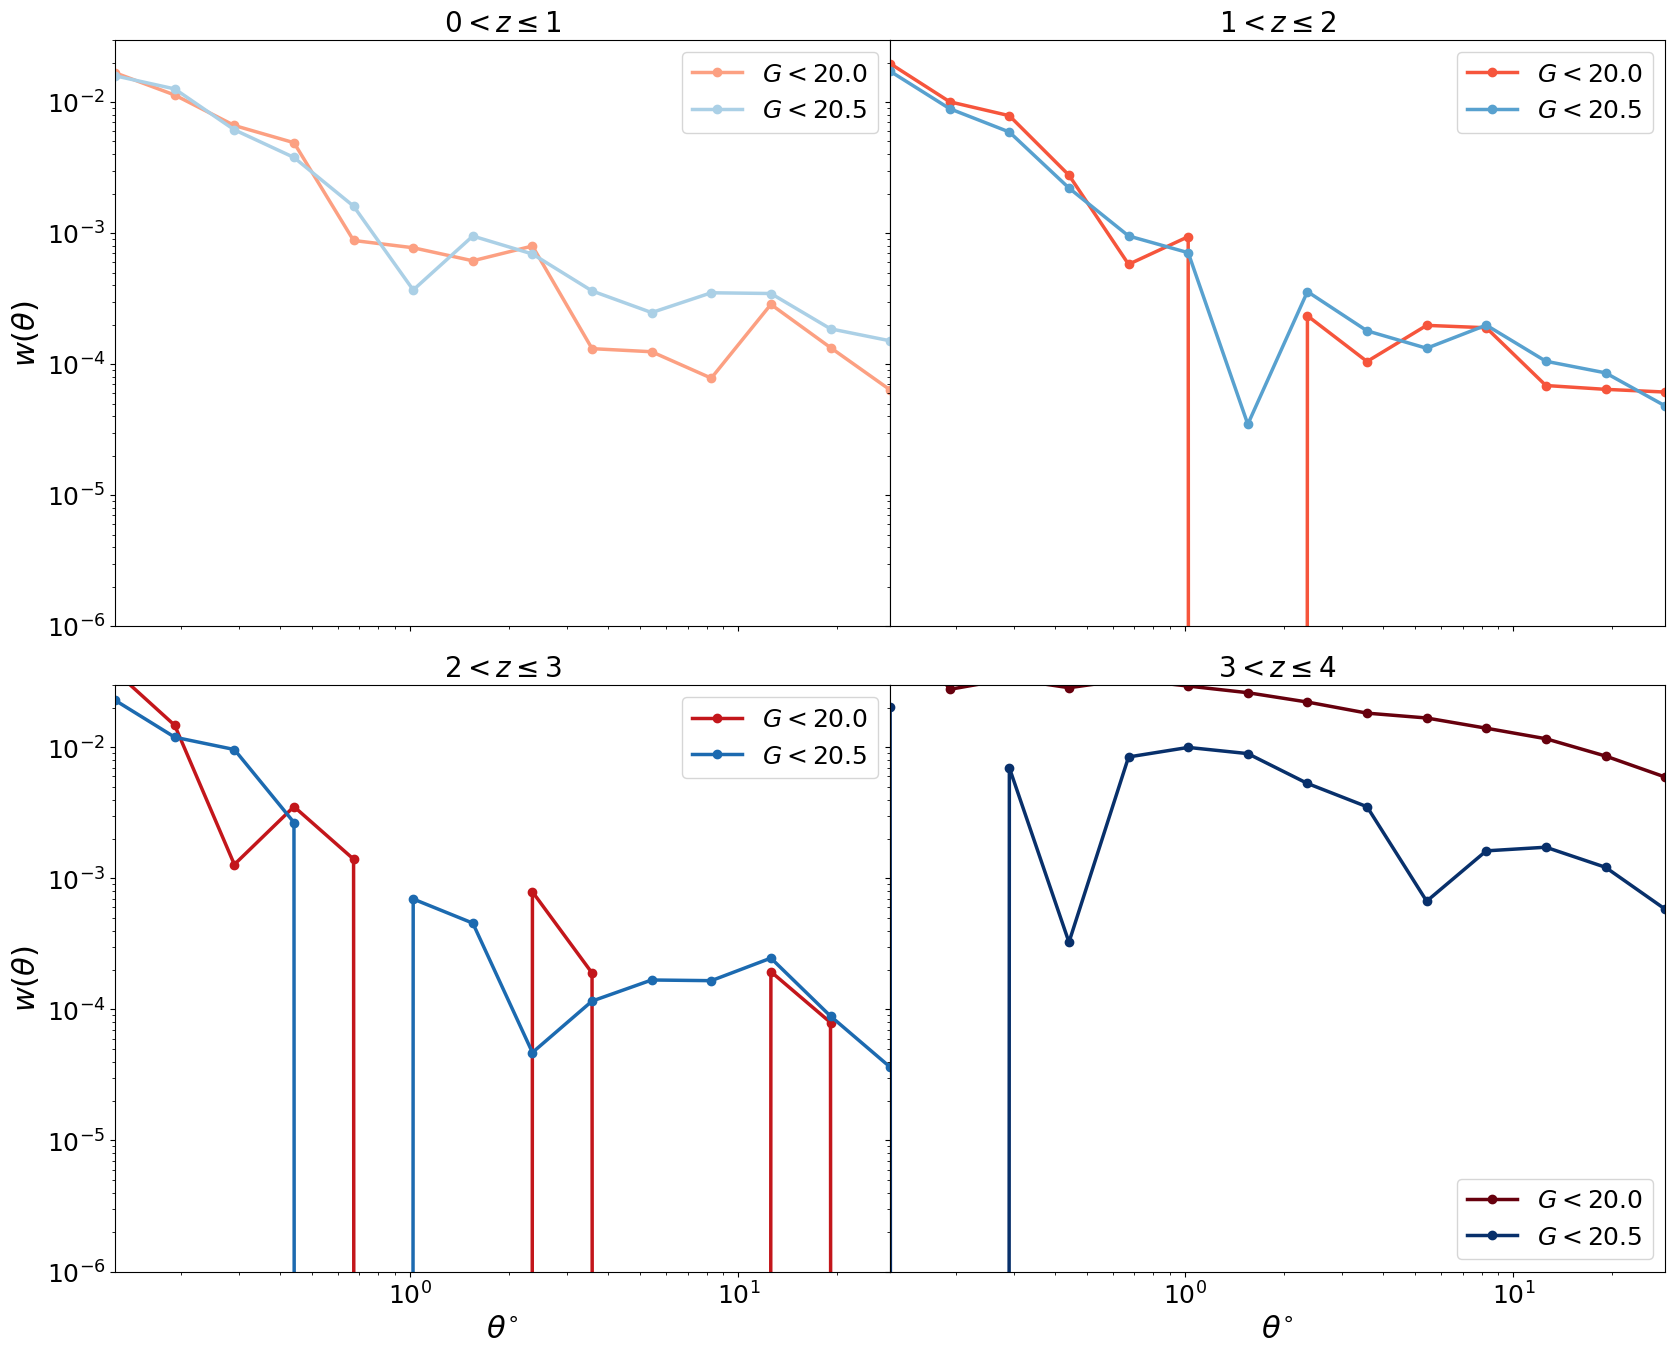

In [90]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin in zbin_array:
    ax1 = fig.add_subplot(gs[zbin])
    for G in [20.0, 20.5]:

        ax1.plot(quaia.recenter(thetabins), wtheta[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmaps[G][zbin])
        ax1.set_title('${}<z \leq{}$'.format(zbin, zbin+1))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.legend()
        if zbin%2==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])
        if zbin<2:
            ax1.set_xticklabels([])
        else:
            ax1.set_xlabel(r'$\theta^{\circ}$')

plt.show()